In [1]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[2, 5, 9, 19, 24, 33])

nb_name = "02_QC_filtering.ipynb"

_compare_version(nb_name)

# 02 - QC and filtering
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Quality control**

We must ensure that all cellular barcode data correspond to viable cells.

To ensure this quality control (QC) is mandatory and for ATAC-seq data based on 4 key aspects:

1. The signal-to-noise, either via i) the enrichment of known regions, or ii) the determination of the ratio of fragments in peaks (FRiP).
2. The total number of unique fragments, also known as library complexity.
3. The fraction of reads derived from mitochondrial DNA vs. nuclear DNA.
4. The Fragment Length Distribution.

**DOI: [10.1186/s13059-020-1929-3](https://doi.org/10.1186/s13059-020-1929-3)**

On the single cell scale additional aspects, such as multiplets have to be taken into account.

**DOI: [10.1038/s41467-021-21583-9](https://doi.org/10.1038/s41467-021-21583-9)**

Based on QC related columns stored in the .obs we can filter for high quality cells based on all these aspects in this notebook.

**Feature Selection**

For subsequent processing steps such as dimension reduction, embedding and clustering, the filtering of features and the selection of highly variable features can be conducive.

Therefore this notebooks provides steps to exclude regions from sex chromosomes and mitochondrial chromosomes and to select highly variabele features.

____________

## 2 - Setup

In [2]:
# sctoolbox modules
import sctoolbox
import sctoolbox.tools.qc_filter as qc
import sctoolbox.utils as utils
import sctoolbox.tools as tools
import sctoolbox.plotting as pl
from sctoolbox import settings

import peakqc.fld_scoring as fld
import matplotlib.pyplot as plt
import pandas as pd
import scrublet as scr
from pathlib import Path
import uropa

sctoolbox.settings.settings_from_config("config.yaml", key="02")

with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(sctoolbox.utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Created directory: ../figures/02_QC/
Created directory: ../report/02_QC/


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,pandas,2.3.3
2,anndata,0.12.6
3,scanpy,1.11.5
4,numpy,2.3.5
5,peakqc,0.1.3
6,uropa,4.0.3
7,sctoolbox,NA


_____________

## 3 - Load anndata
Uses the anndata object written by the previous notebook.

**Checkpoint**  
Before the filtering is performed, some ATAC-specific QC metrics are calculated. This may take some time.  
To speed up the process of redoing the QC filtering, a checkpoint file is saved after the metrics are calculated, which is used by default if it exists.

To disable the use of the checkpoint file, set `use_checkpoint` to `False`. If no checkpoint file is found, it is automatically disabled.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [3]:
use_checkpoint = True # Use checkpoint file if True

---

In [4]:
# Checkpoint file
checkpoint = "anndata_qc_metric_checkpoint.h5ad"
# Set checkpoint as Path to enable checks
checkpoint_file = Path(f"{sctoolbox.settings.adata_output_dir}/{checkpoint}")
if use_checkpoint and not checkpoint_file.is_file():
    print("No checkpoint found. Enabling the calculation of the QC metrics.")
    use_checkpoint = False

No checkpoint found. Enabling the calculation of the QC metrics.


In [5]:
adata_name = checkpoint if use_checkpoint else "anndata_1.h5ad"
adata = utils.adata.load_h5ad(adata_name)

with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)
    display(adata.var)

[INFO] The adata object was loaded from: ../adatas/anndata_1.h5ad


AnnData object with n_obs × n_vars = 10246 × 165434
    obs: 'sample', 'disease state', 'tissue', 'selected cell types'
    var: 'chr', 'start', 'end'
    uns: 'sctoolbox'

,sample,disease state,tissue,selected cell types
barcode,,,,
AAACGAAAGAGAGGTA-1,sample 1,healthy,blood,PBMCs
AAACGAAAGCAGGAGG-1,sample 1,healthy,blood,PBMCs
...,...,...,...,...
TTTGTGTTCTGATCTT-1,sample 1,healthy,blood,PBMCs
TTTGTGTTCTTACTCA-1,sample 1,healthy,blood,PBMCs


,chr,start,end
new_index,,,
chr1:9772-10660,chr1,9772,10660
chr1:180712-181178,chr1,180712,181178
...,...,...,...
KI270713.1:29676-30535,KI270713.1,29676,30535
KI270713.1:36913-37813,KI270713.1,36913,37813


____________

## 4 - QC and filtering
<hr style="border:2px solid black"> </hr>

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [6]:
# Set the column in adata.obs containing the biological condition to evaluate
condition_column = "sample"

# Absolute minimum number of features for pre-selection of cells before QC 
min_genes = 1

# Choose whether to binarize the X matrix
binarize_mtx = False  # True or False; convert matrix to binary

# Optional: Plot STARsolo quality if a path is given
quant_folder = ""

# correction of ambient signal using scAR",
# Caution this process is expensive and thus will take time to run!",
# Requires the raw (unfiltered) AnnData object containing all droplets.",
path_raw_adata = ""  # The path to the raw h5ad file. Leave empty to skip.",
epochs = 150  # Number of iterations for the model."

# Available threads
threads = 8

# ----------------------- Doublet removal ------------------------

# Use native scrublet or the scanpy wrapper (scanpy: optimized for RNA)
use_native_scrublet = True

# Default threshold to apply doublet removal on (None for automatic threshold)
doublet_threshold = 0.4

----------------------

In [7]:
if not use_checkpoint:
    # Ensure that condition column is a category
    adata.obs[condition_column] = adata.obs[condition_column].astype("category")

### 4.1 - Show STARsolo quality (optional)

If the data was mapped using STARsolo, use the parameter to set the path to the STARsolo runs and plot quality measures across runs. The path must be a folder, e.g. "path/to/starsolo_output", which contains folders per condition e.g. "cond1", "cond2", etc.

In [8]:
if quant_folder != "":
    _ = pl.qc_filter.plot_starsolo_quality(quant_folder, save="starsolo_quality.pdf")
    _ = pl.qc_filter.plot_starsolo_UMI(quant_folder, ncol=3, save="starsolo_cell_selection.pdf")

_______

### 4.2 - Remove empty cells and features

In [9]:
if not use_checkpoint:
    print('original shape:')
    print(adata.shape)
    print('Removing empty features and cells...')

    adata = adata[adata.X.sum(axis=1) > 0]
    adata = adata[:, adata.X.sum(axis=0) > 0]

print('new shape:')
print(adata.shape)

original shape:
(10246, 165434)
Removing empty features and cells...
new shape:
(10246, 165434)


________

### 4.3 Add ATAC specific metrices
<hr style="border:1px solid black"> </hr>

Add ATAC specific QC-metrics to the `.obs` table.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [10]:
## 1. Source of fragments

# Either provide a bamfile or a bedfile containing fragments
fragments_file = '../../../data/ATAC/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv'

# Name of the bam-tag which contains the barcode information (usually 'CB')
barcode_tag = 'CB'

## 2. Choose actions to be done

# 2.1 calculate fragment length distribution score
calculate_fld_score = True

# 2.2 calculate overlap between fragments and regions
calculate_overlap = True

# Additional settings for the overlap
region_name = 'promoters'
regions_file = '../../../data/ATAC/homo_sapiens.110.promoters2000.gtf'
genes_gtf = '../../../data/ATAC/homo_sapiens.110.genes.gtf'  # this is also used for gene annotation

---

#### 4.3.1 - Check barcode tag 
If a bamfile is provided this checks if the barcodes are available in the anndata object

In [11]:
use_bam = fragments_file.endswith("bam")
if use_bam and not use_checkpoint:
    tools.bam.check_barcode_tag(adata, fragments_file, barcode_tag)

---

#### 4.3.2 - Score fragment length distributions (FLD Score)
This ATAC specific quality control metric scores the fragment length distribution pattern of individual cells. This step utilizes PEAKQC for the score calculation. Choose if this score should be calculated and provide a file containing the fragments of the features. As input a bamfile with the raw reads or a bedfile containing fragments are suitable.

In [12]:
if calculate_fld_score and not use_checkpoint:
    fld.add_fld_metrics(adata=adata,
                        fragments=fragments_file,
                        barcode_col=None,
                        barcode_tag=barcode_tag,
                        chunk_size_bam=1000000,
                        regions=None,
                        peaks_thr=10,
                        wavelength=150,
                        sigma=0.4,
                        plot=False,
                        save_density=None,
                        save_overview=None,
                        sample=0)

    adata.obs

Using fragments file...
Count insertsizes from fragments...
Processing chunk 0 on shard 0
Processing chunk 1 on shard 1
Processing chunk 2 on shard 2
Processing chunk 3 on shard 3
Processing chunk 4 on shard 0
Processing chunk 5 on shard 1
Processing chunk 6 on shard 2
Processing chunk 7 on shard 3
Processing chunk 8 on shard 0
Processing chunk 9 on shard 1
Processing chunk 10 on shard 2
Processing chunk 11 on shard 3
Processing chunk 12 on shard 0
Processing chunk 13 on shard 1
Processing chunk 14 on shard 2
Processing chunk 15 on shard 3
Processing chunk 16 on shard 0
Processing chunk 17 on shard 1
Processing chunk 18 on shard 2
Processing chunk 19 on shard 3
Processing chunk 20 on shard 0
Processing chunk 21 on shard 1
Processing chunk 22 on shard 2
Processing chunk 23 on shard 3
Processing chunk 24 on shard 0
Processing chunk 25 on shard 1
Processing chunk 26 on shard 2
Processing chunk 27 on shard 3
Processing chunk 28 on shard 0
Processing chunk 29 on shard 1
Processing chunk 30 

Processing Samples: 100%|██████████| 9885/9885 [31:41<00:00,  5.20it/s]


calculating scores using the custom continues wavelet transformation...
add new column: fld_score
add new column: mean_fragment_size
add new column: n_fragments


---

#### 4.3.3 - Calculate an overlap
Compares the amount of fragments within the provided regions (e.g. promoters) against the amount of fragments located in the remaining cell.

In [13]:
if calculate_overlap and not use_checkpoint:
    tools.calc_overlap_fc.fc_fragments_in_regions(
        adata=adata,
        regions_file=regions_file,
        bam_file=fragments_file if use_bam else None,
        fragments_file=fragments_file if not use_bam else None,
        cb_col=None,
        cb_tag=barcode_tag,
        regions_name=region_name,
        threads=threads,
        temp_dir=None
    )

    adata.obs

[INFO] Converting GTF to BED...
[INFO] Finding overlaps...


***** WARNING: File ../../../data/ATAC/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv has inconsistent naming convention for record:
KI270728.1	134171	134542	GATCATGAGCAGGACT-1	1

ERROR: Sort order was unspecified, and file ../../../data/ATAC/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv is not sorted lexicographically.
       Please rerun with the -g option for a genome file.
       See documentation for details.


[INFO] Calculating fold change...
[INFO] Adding results to adata object...
[INFO] cleaning up...
[INFO] removing tempfiles


---

#### 4.3.4 - Calculate fraction of reads in peaks (FRiP Score)
The Fraction of reads in Peaks (FRiP Score) can be used to evaluate the overall signal-to-noise ratio. It provides information about the fraction of reads located within the called peak.

In [14]:
if not use_checkpoint:
    adata, total_frip = tools.frip.calc_frip_scores(adata, 
                                                    fragments_file, 
                                                    temp_dir='')
    adata.obs

[INFO] writing regions to bedfile


extract adata.var regions: 165434it [00:08, 18751.21it/s]

[INFO] overlapping bedfiles



***** WARNING: File regions.bed has inconsistent naming convention for record:
KI270727.1	52092	52991

***** WARNING: File regions.bed has inconsistent naming convention for record:
KI270727.1	52092	52991



[INFO] reading in bedfiles
[INFO] calculating total number of fragments and overlaps
[INFO] total_frip: 0.649033517140268
[INFO] calculating FRiP scores per barcode
[INFO] count fragments per barcode
[INFO] counting fragments per barcode
[INFO] counting fragments per barcode
[INFO] calculating FRiP score per barcode and adding it to adata.obs


---

#### 4.3.5 - Calculate transcription start site enrichment (TSSe)
As for the FRiP Score the Transcription Start Site Enrichment (TSSE) Score is used to evaluate the signal-to-noise ratio. It is a score that describes the proximity of signal to transcription start sites.

[INFO] adding tSSe score to adata object
[INFO] Preparing gtf file for annotation...
[INFO] - Reading gtf with Tabix
[INFO] - Index of gtf not found - trying to index gtf
[INFO] - Reading gtf with Tabix
[INFO] Done preparing gtf!
[INFO] building temporary TSS file
[INFO] fragments are sorted
[INFO] overlapping fragments with TSS
[INFO] opening overlap file


***** WARNING: File ../../../data/ATAC/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv has inconsistent naming convention for record:
KI270728.1	134171	134542	GATCATGAGCAGGACT-1	1

ERROR: Sort order was unspecified, and file ../../../data/ATAC/10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv is not sorted lexicographically.
       Please rerun with the -g option for a genome file.
       See documentation for details.


[INFO] aggregating fragments


Aggregating: 100%|██████████| 62700/62700 [07:17<00:00, 143.19it/s]


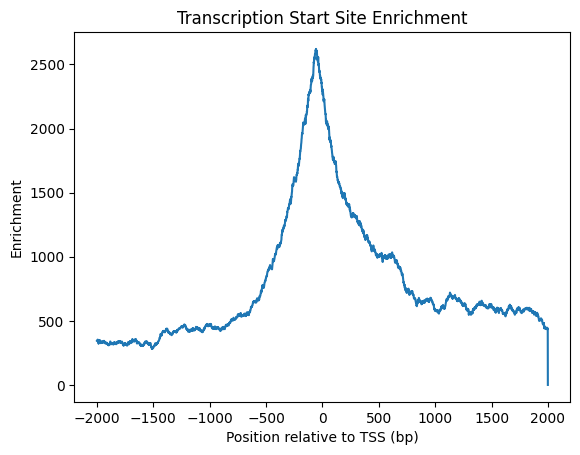

[INFO] calculating bias
[INFO] calculating per base tSSe
[INFO] calculating global tSSe score
[INFO] cleaning up temporary files


In [15]:
if not use_checkpoint:
    adata, tSSe_df = tools.tsse.add_tsse_score(adata,
                                               fragments=fragments_file,
                                               gtf=genes_gtf,
                                               negativ_shift=2000,
                                                positiv_shift=2000,
                                               edge_size_total=100,
                                               edge_size_per_base=50,
                                               min_bias=1.0,
                                               keep_tmp=False,
                                               temp_dir="",
                                               plot=True,
                                               return_aggs=True)

#### Save checkpoint file

In [16]:
if not use_checkpoint:
    utils.adata.save_h5ad(adata, checkpoint)

[INFO] The adata object was saved to: ../adatas/anndata_qc_metric_checkpoint.h5ad


---

### 4.4 - Denoising
Remove ambient signal and technical noise from the count matrix using [scAR](https://www.biorxiv.org/content/10.1101/2022.01.14.476312v4). The tool estimates the ambient profile by averaging cell-free droplets. An autoencoder neural network later corrects the count matrix.

In [17]:
import scanpy as sc

if path_raw_adata:
    print("Loading raw anndata...")
    adata_raw = sc.read_h5ad(path_raw_adata)
    print("Denoising data, this will take a while...")
    adata = qc.denoise_data(adata, adata_raw, feature_type='Peaks', epochs=epochs,
                            verbose=False, save='droplets_kneeplot.pdf', report="05_denoise.png")

_______

### 4.5 - Binarize matrix
Binarizes the count matrix to be either 0 or 1. This corresponds to the general view that chromatin is either accessible (1) or inaccesible (0). However, it is still under debate whether binarization may result in a loss of information. Therefore,  binarization is optional.

**DOI: [10.1038/s41592-023-02112-6](https://doi.org/10.1038/s41592-023-02112-6)**

In [18]:
# binarize
if binarize_mtx:
    # save raw matrix
    adata.layers["raw"] = adata.X.copy()
    
    adata.X[adata.X != 0] = 1
    
    # save binarized matrix
    adata.layers["binarized"] = adata.X.copy()
    
    utils.io.update_yaml({"binarized": True}, yml="method.yml", path_prefix="report")

_______

### 4.6 Calculate and remove doublets
Doublets are artifacts where two (doublet) or more (multiplet) cells receive the same barcode. As multiplets behave as a joined feature set of the collected cells they may show up as a separate group in downstream analysis, thus potentially skewing results. Therefore, it is recommended to remove doublets.

**DOI: [10.1016/j.cels.2018.11.005](https://doi.org/10.1016/j.cels.2018.11.005)**

[INFO] Sending 1 batches to 8 threads


Scrublet per group:   0%|          | 0/1 [00:00<?, ?it/s]

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/scrublet/helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.36
Detected doublet rate = 6.8%
Estimated detectable doublet fraction = 60.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 11.2%
Elapsed time: 114.7 seconds
Detected doublet rate = 4.8%
Estimated detectable doublet fraction = 53.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 9.0%


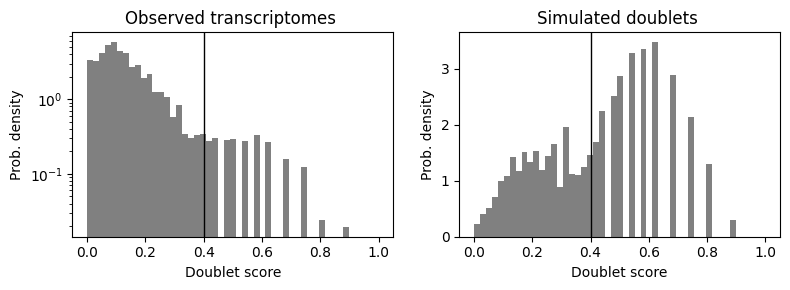

In [19]:
tools.qc_filter.estimate_doublets(adata, use_native=use_native_scrublet, groupby=condition_column, threads=threads, threshold=doublet_threshold)

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [20]:
# Remove predicted doublet
remove_doublets = True

---

In [21]:
if remove_doublets:
    # Remove the duplicates from adata
    tools.qc_filter.filter_cells(adata, "predicted_doublet", name="doublet", report="03_doublet_info.txt")

[INFO] Filtered 492 doublet elements from AnnData.obs (10246 -> 9754).


In [22]:
# remove empty features
adata = adata[adata.X.sum(axis=1) > 0]
adata = adata[:, adata.X.sum(axis=0) > 0]

______

### 4.7 - Cell filtering
<hr style="border:1px solid black"> </hr>

Identify low quality cells and remove them from the dataset. Low quality cells are investigated using several metrics, which can be choosen below.

In [23]:
# Recalculate standard QC metrics (counts...)
adata = tools.qc_filter.calculate_qc_metrics(adata, var_type='features')

# drop total_counts as it is the same as n_features
adata.obs.drop(columns=["total_counts", "log1p_total_counts"], inplace=True)

# Remove peaks with 0 count
zero_bool = adata.var["n_cells_by_counts"] == 0
adata = adata[:,~zero_bool]

In [24]:
# available obs columns
with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata.obs)

,sample,disease state,tissue,selected cell types,fld_score,mean_fragment_size,n_fragments,fold_change_promoters_fragments,frip,tsse_score,doublet_score,predicted_doublet,n_features,log1p_n_features
barcode,,,,,,,,,,,,,,
AAACGAAAGAGAGGTA-1,sample 1,healthy,blood,PBMCs,1236.596857,131.17,55681,0.385877,0.755841,7.305137,0.048303,False,12605,9.441928
AAACGAAAGCAGGAGG-1,sample 1,healthy,blood,PBMCs,1411.451173,123.53,18024,0.557725,0.764383,7.814169,0.073210,False,5392,8.592857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCTGATCTT-1,sample 1,healthy,blood,PBMCs,1669.071202,135.55,49822,0.329239,0.692217,4.656945,0.130035,False,13992,9.546312
TTTGTGTTCTTACTCA-1,sample 1,healthy,blood,PBMCs,2070.700868,144.87,51305,0.381827,0.599754,6.906920,0.341463,False,10882,9.294957


Any numeric column shown above can be used as filter metric. Here is a description of the commonly available metrics:

| Metric | Description | Recommendation |
|--------|-------------|----------------|
|fld_score|A score describing the fit of the fragment length distribution to the expected nucleosome driven fragment length distribution.|Bigger values are better.|
|mean_fragment_size|The mean size of the DNA fragments of each cell.|Good quality data shows an enrichment for nucleosome free (<147bp) or low number nucleosome fragments.|
|n_fragments|The number of DNA fragments per cell.|A lower bound should consider the trade of between a more lenient approach that will keep rarer cell types and low quality cells alike and a stricter threshold that filters more of both groups. The upper threshold should filter outliers as these are likely to be artifacts. Should correlate with `n_features`. |
|fold_change_promoters_fragments|The comparison of fragments within promoter regions vs. outside of promoter regions.|A higher value (less fragments outside promoters) is preferable as fragments outside of promoters are considered noise.|
|frip|Fraction of reads in peaks. The fraction of reads that are located within the called peaks (0-1).|Similar to `fold_change_promoters_fragments` higher is better as a high number of reads outside of the called peaks is considered a sign for bad quality.|
|tsse_score|Transcription start site enrichment score in other words a score that describes the proximity of signal to transcription start sites.|More is better. However, extremely high values should be filtered as they are likely artifacts. The lower bound should be `>0` to remove low quality cells.|
|n_features|The number of features (peaks) found within the respective cell. This should correlate with `n_fragments` (the detected DNA fragments per cell).|Needs similar consideration as `n_fragments`.|
|log1p_n_features|Same as n_features but on a logarithmic scale.|See above.|

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [31]:
# Decide whether to estimate thresholds individual per condition (False) or globally (True)
global_threshold = True

# Before filtering the impact of the individual filters are plotted by an UpSet plot.
# To restrict complexity of the plot the plotted combinations can be limited below.
limit_combinations = 2 # Either provide the combination grade as Integer or None to include all

# Set initial filter thresholds
# The thresholds can be interctively changed later on
# Note: Only metrics provided below are available for filtering 
default_thresholds = {
    'n_features': {'min': 500, 'max': 20000},
    'log1p_n_features': {'min': None, 'max': None},
    'fld_score': {'min': None, 'max': None},
    'frip': {'min': None, 'max': None},
    'tsse_score': {'min': None, 'max': 10}
    # add additional threshold based on the available columns shown above
    # format: '<obs clolumn>': {'min': <threshold|None>, 'max': <threshold|None>}
    # None = automatically derive initial threshold
    # float('inf') or float('-inf') = no filter
}

__________

#### 4.7.1 Adapt thresholds

In [32]:
groupby = condition_column if global_threshold is False else None
initial_thresholds = tools.qc_filter.get_thresholds(adata,
                                                    default_thresholds, 
                                                    groupby=groupby)
obs_columns = list(initial_thresholds.keys())
tools.qc_filter.thresholds_as_table(initial_thresholds)

,Parameter,Minimum,Maximum
0,n_features,500.000000,20000.000000
1,log1p_n_features,8.454741,10.172129
2,fld_score,1072.850667,2421.454534
3,frip,0.572947,0.792167
4,tsse_score,3.863848,10.000000


The plot below estimates the impact each metric (and combination of metrics) would have on the data. Metrics that filter the same amount of cells independent of being alone or combined with other metrics can be disregarded as they have little effect on the overall outcome of the filtering.

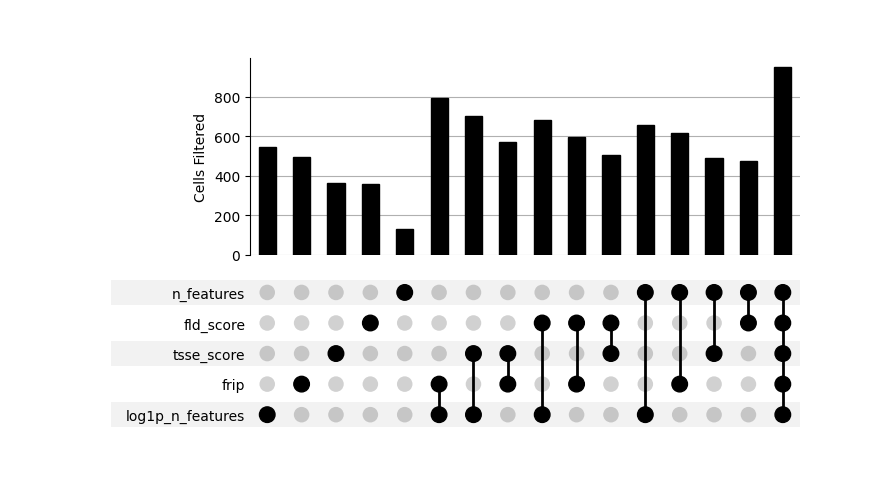

In [33]:
_ = pl.qc_filter.upset_plot_filter_impacts(adata, 
                                           thresholds=initial_thresholds,
                                           groupby=groupby,
                                           limit_combinations=limit_combinations)

In [34]:
%matplotlib widget

# Plot violins and sliders
obs_figure, obs_slider_dict = pl.qc_filter.quality_violin(
    adata,
    columns=obs_columns,
    groupby=condition_column,
    which="obs",
    thresholds=initial_thresholds,
    global_threshold=global_threshold,
    title="Cell quality control (before)",
    save="cell_filtering.png"
)
obs_figure

[INFO] Saving figure to ../figures/02_QC/cell_filtering.png


#### 4.7.2 - Apply cell filtering

In [35]:
# Get final thresholds
final_thresholds = pl.qc_filter.get_slider_thresholds(obs_slider_dict)
tools.qc_filter.thresholds_as_table(final_thresholds, report="01_cell_filter_info.png") # show thresholds

,Parameter,Minimum,Maximum
0,n_features,500.000000,20000.000000
1,log1p_n_features,8.454741,10.172129
2,fld_score,1072.850667,2421.454534
3,frip,0.572947,0.792167
4,tsse_score,3.863848,10.000000


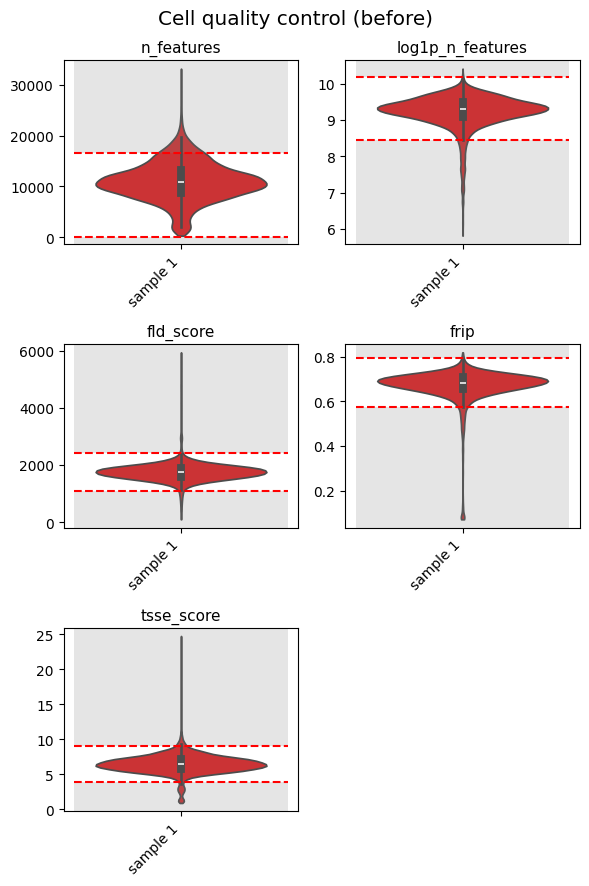

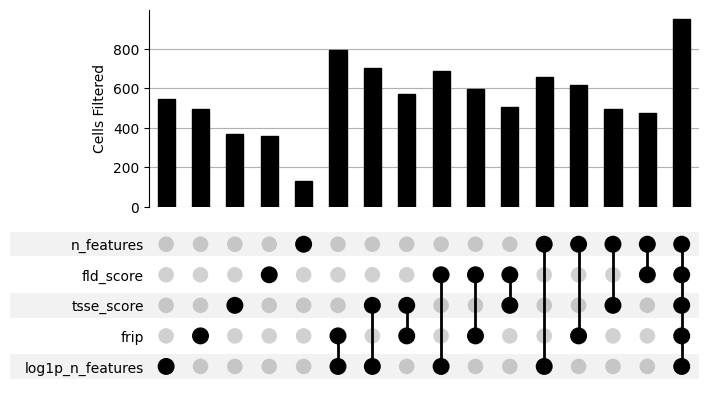

In [36]:
%matplotlib inline
plt.close()  # close previous figure

_ = pl.qc_filter.upset_plot_filter_impacts(adata, 
                                           thresholds=final_thresholds, 
                                           groupby=groupby,
                                           limit_combinations=limit_combinations,
                                           report="03_cell_filter_impact.png")

[INFO] Saving figure to ../figures/02_QC/cell_filtering_scatter.pdf


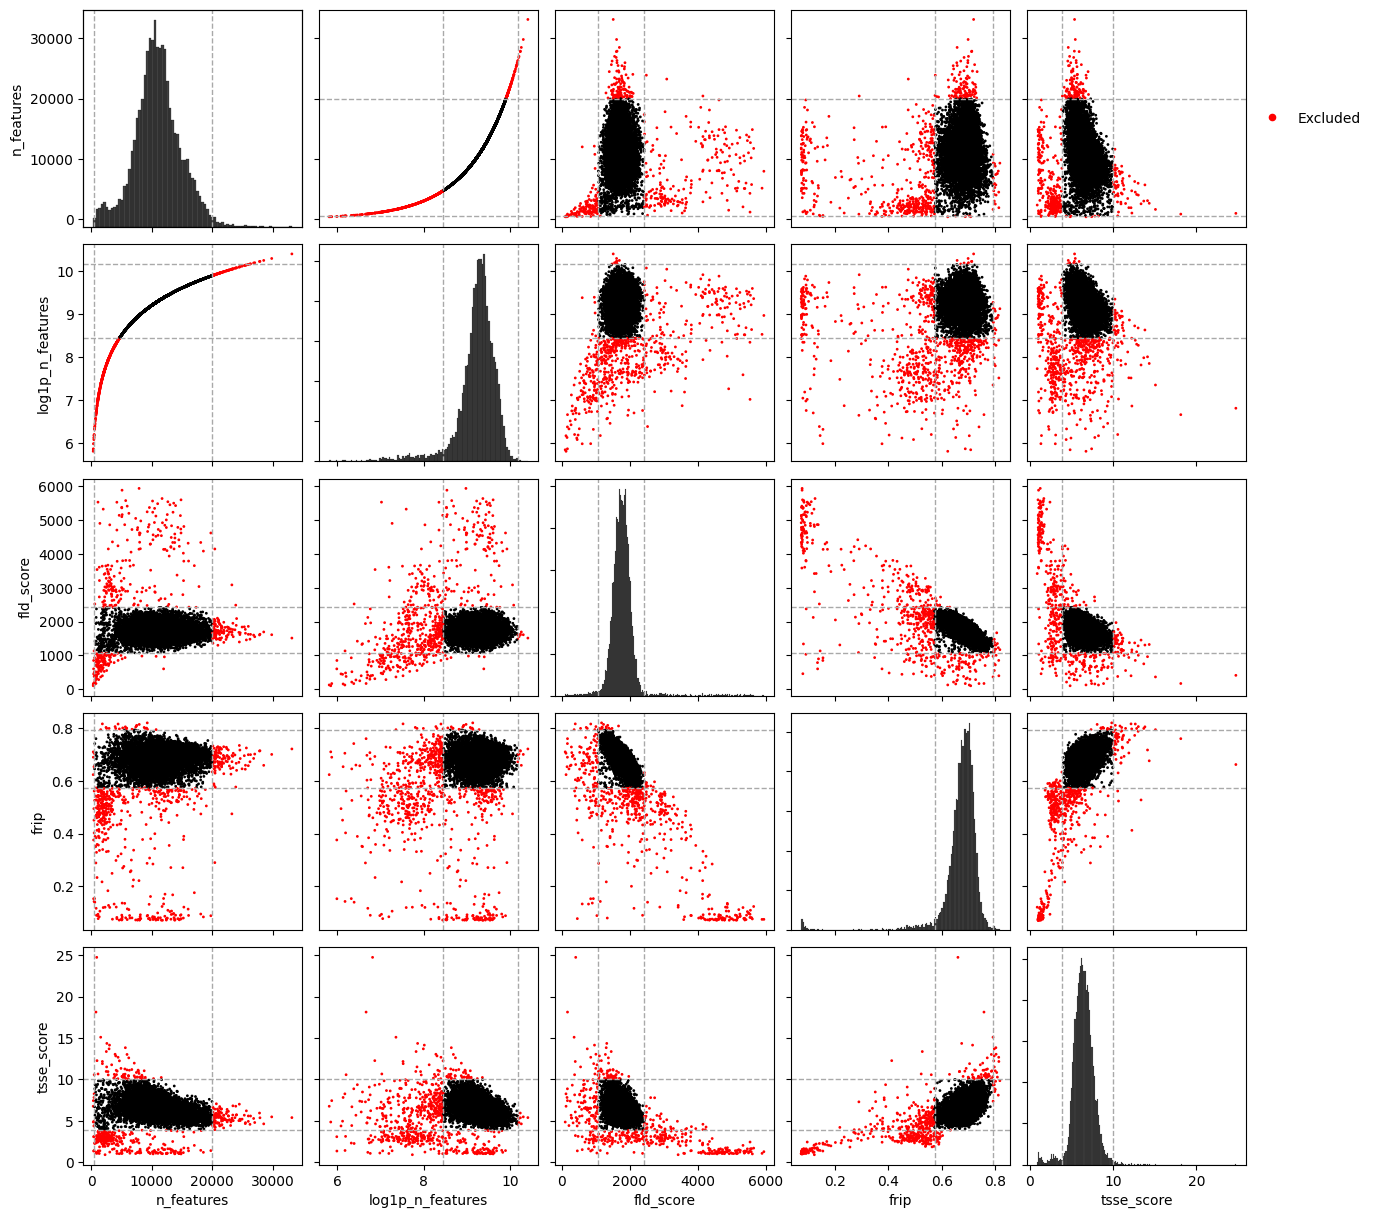

In [37]:
# Show pairwise comparisons of column values w/ thresholds (mean values in case thresholds are grouped)
if len(final_thresholds) > 1:
    mean_thresholds = tools.qc_filter.get_mean_thresholds(final_thresholds)
    _ = pl.general.pairwise_scatter(adata.obs, obs_columns, thresholds=mean_thresholds,
                                    save="cell_filtering_scatter.pdf", report="02_cell_filter_scatter.png")

In [38]:
tools.qc_filter.apply_qc_thresholds(adata, final_thresholds, report="03_cell_filter_info.txt")

# remove empty features after cell filtering
adata = adata[:, adata.X.sum(axis=0) > 0]

[INFO] Filtered 951 threshold elements from AnnData.obs (9754 -> 8803).


#### 4.7.3 - Show data after filtering

[INFO] Saving figure to ../figures/02_QC/cell_filtering_final.pdf


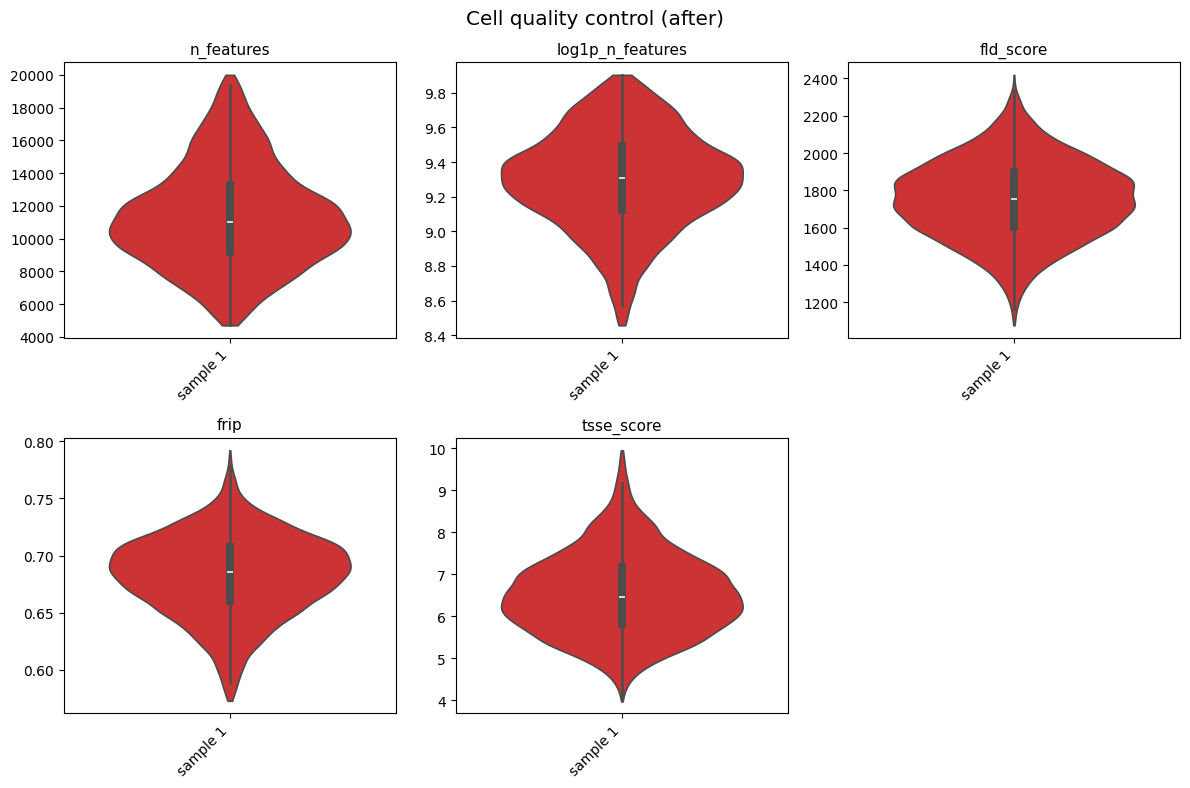

In [39]:
#Plot violins and sliders
figure, slider_dict = pl.qc_filter.quality_violin(
    adata,
    columns=obs_columns,
    groupby=condition_column,
    which="obs", ncols=3,
    global_threshold = global_threshold,
    title="Cell quality control (after)",
    save="cell_filtering_final.pdf",
    report="01_cell_filter.png"
)
plt.show()

## 5 - Feature processing
<hr style="border:2px solid black"> </hr>

This section filters features (peaks). The user has the option to remove features located on the mitochondrial chromosome and features on either of the allosomes.

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [40]:
# Removal of feature subsets
filter_chrM = True  # True or False; filtering out chrM
filter_xy = True    # True or False; filtering out chrX and chrY

__________

### 5.1 - Filter additional marked features

In [41]:
with open(Path(settings.report_dir) / "04_feature_filter_info.txt", "w") as f:
    def log_helper(f, tf, m, fh):
        msg = f"Found and removed {sum(not v for v in f)} ({100 - sum(f) / tf * 100:.2f}%) {m} features of {tf} total features."
        fh.write(msg + "\n")
        utils.io.update_yaml({m: sum(not v for v in f)}, yml="method.yml", path_prefix="report")
        print(msg)
    
    if filter_chrM:
        print("Removing chromosomal features...")
        non_m = [not name.startswith('chrM') for name in adata.var_names]  # remove chrM
        log_helper(non_m, len(adata.var), "mitochondrial", f)
        adata = adata[:, non_m]

    if filter_xy:
        print("Removing gender related features...")
        non_xy = [not name.startswith('chrY') and not name.startswith('chrX') for name in adata.var_names]
        log_helper(non_xy, len(adata.var), "gender", f)
        adata = adata[:, non_xy]

Removing chromosomal features...
Found and removed 0 (0.00%) mitochondrial features of 165434 total features.
Removing gender related features...
Found and removed 5071 (3.07%) gender features of 165434 total features.


_________

## 6 - Annotate regions to genes
<hr style="border:2px solid black"> </hr>

This function uses [UROPA](https://doi.org/10.1038/s41598-017-02464-y) to annotate regions to genes with a gtf file containing the genes as reference. The annotation is skipped if no gene location GTF was supplied in section 4.3.

In [42]:
if genes_gtf:
    tools.peak_annotation.annotate_adata(
        adata,
        genes_gtf,
        config=None,
        best=True,
        threads=settings.threads,
        coordinate_cols=None,
        temp_dir="tmp",
        inplace=True,
        report=True
    )

[INFO] Setting up annotation configuration...
[INFO] Config dictionary: {'queries': [{'distance': [10000, 1000], 'feature_anchor': ['start'], 'feature': ['gene'], 'name': 'promoters'}], 'priority': True, 'show_attributes': ['all'], 'output_by_query': False}
[INFO] Setting up genomic regions to annotate...
[INFO] No column names supplied falling back to default names ['chr', 'start', 'end']
[INFO] Preparing gtf file for annotation...
[INFO] - Reading gtf with Tabix
[INFO] - Index of gtf not found - trying to index gtf
[INFO] - Reading gtf with Tabix
[INFO] Done preparing gtf!
[INFO] Annotating regions...
[INFO] Formatting annotations...
[INFO] Finished annotation of features! The results are found in the .var table.
[INFO] removing tempfiles


In [43]:
if genes_gtf:
    with pd.option_context("display.max.rows", 5, "display.max.columns", None):
        display(adata.var)

,chr,start,end,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,annotation_feature,gene_strand,gene_start,gene_end,annotation_query,query_name,distance_to_gene,gene_anchor,gene_ovl_peak,peak_ovl_gene,relative_location_to_gene,gene_id,gene_version,gene_name,gene_source,gene_biotype
chr1:9772-10660,chr1,9772,10660,52,0.010662,0.010606,99.466885,104.0,4.653960,gene,+,11868.0,14409.0,0.0,promoters,1652.0,start,0.0,0.0,Upstream,ENSG00000290825,1,DDX11L2,havana,lncRNA
chr1:180712-181178,chr1,180712,181178,109,0.021325,0.021100,98.882510,208.0,5.342334,gene,+,182695.0,184174.0,0.0,promoters,1750.0,start,0.0,0.0,Upstream,ENSG00000279928,2,DDX11L17,havana,unprocessed_pseudogene
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KI270713.1:29676-30535,KI270713.1,29676,30535,223,0.042547,0.041666,97.713758,415.0,6.030685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KI270713.1:36913-37813,KI270713.1,36913,37813,172,0.037216,0.036540,98.236621,363.0,5.897154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


________

## 7 - Save filtered adata
<hr style="border:2px solid black"> </hr>
Store the final results

In [44]:
adata

AnnData object with n_obs × n_vars = 8803 × 160363
    obs: 'sample', 'disease state', 'tissue', 'selected cell types', 'fld_score', 'mean_fragment_size', 'n_fragments', 'fold_change_promoters_fragments', 'frip', 'tsse_score', 'doublet_score', 'predicted_doublet', 'n_features', 'log1p_n_features'
    var: 'chr', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'annotation_feature', 'gene_strand', 'gene_start', 'gene_end', 'annotation_query', 'query_name', 'distance_to_gene', 'gene_anchor', 'gene_ovl_peak', 'peak_ovl_gene', 'relative_location_to_gene', 'gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype'
    uns: 'sctoolbox', 'scrublet'

In [45]:
#Saving the data
adata_output = "anndata_2.h5ad"
utils.adata.save_h5ad(adata, adata_output, report=["dataset_overview.md", "obs.png", "var.png"])

[INFO] The adata object was saved to: ../adatas/anndata_2.h5ad


In [46]:
sctoolbox.settings.close_logfile()